# Razonamiento simbólico con Python: invernadero inteligente

**Nivel:** principiante  
**Entorno:** Google Colab  
**Tema:** hechos, reglas e inferencia automática

## Contexto del caso

Un invernadero inteligente tiene sensores que informan si el suelo está seco, si hace calor, si hay luz suficiente y si se detecta una persona. Queremos que un sistema de IA tome decisiones explicables usando reglas escritas por una persona.

Por ejemplo: si el suelo está seco, el sistema puede recomendar riego. Si además hace calor, puede recomendar ventilación. La computadora no aprende estas reglas a partir de ejemplos: las aplica mediante lógica.

Este notebook muestra un sistema simbólico sencillo llamado **encadenamiento hacia adelante**: empieza con hechos conocidos, aplica reglas y agrega nuevas conclusiones hasta que ya no puede deducir nada más.

## Objetivos de aprendizaje

- Diferenciar hechos, reglas y conclusiones.
- Construir un motor de inferencia pequeño.
- Observar cómo una conclusión puede activar otra regla.
- Leer una explicación del razonamiento paso a paso.
- Visualizar qué reglas se activaron y qué acciones se recomiendan.

### Supuestos didácticos

Los sensores se representan como palabras (`suelo_seco`, `temperatura_alta`, etc.). En un sistema real, otro programa convertiría los valores numéricos de los sensores en estos símbolos.

## 1. Preparar las herramientas

Usaremos `pandas` para mostrar resultados en tablas y `matplotlib` para crear gráficos. Ambas bibliotecas suelen estar disponibles directamente en Google Colab.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
print("Entorno listo para el razonamiento simbólico.")

Entorno listo para el razonamiento simbólico.


## 2. Definir los hechos conocidos

Un hecho es una afirmación que el sistema considera verdadera en este momento. El conjunto `hechos_iniciales` simula la lectura actual del invernadero. No contiene todavía decisiones; solo información observada.

In [2]:
hechos_iniciales = {
    "suelo_seco",
    "temperatura_alta",
    "luz_suficiente",
    "persona_detectada"
}

print("Hechos observados por los sensores:")
for hecho in sorted(hechos_iniciales):
    print(" ✓", hecho)

Hechos observados por los sensores:
 ✓ luz_suficiente
 ✓ persona_detectada
 ✓ suelo_seco
 ✓ temperatura_alta


## 3. Definir las reglas del conocimiento

Cada regla tiene tres partes: un nombre, unas condiciones y una conclusión. La regla se activa solamente cuando todas sus condiciones están presentes entre los hechos. Las reglas son transparentes: podemos leerlas y discutirlas con una persona experta.

In [3]:
reglas = [
    {"nombre": "R1 - detectar necesidad de riego",
     "si": {"suelo_seco"}, "entonces": "necesita_riego"},
    {"nombre": "R2 - proteger plantas del calor",
     "si": {"temperatura_alta"}, "entonces": "necesita_ventilacion"},
    {"nombre": "R3 - autorizar riego con luz suficiente",
     "si": {"necesita_riego", "luz_suficiente"},
     "entonces": "activar_bomba_agua"},
    {"nombre": "R4 - avisar al encargado",
     "si": {"persona_detectada", "necesita_ventilacion"},
     "entonces": "mostrar_alerta"}
]

for regla in reglas:
    condiciones = " Y ".join(sorted(regla["si"]))
    print(f"{regla['nombre']}: SI {condiciones} → ENTONCES {regla['entonces']}")

R1 - detectar necesidad de riego: SI suelo_seco → ENTONCES necesita_riego
R2 - proteger plantas del calor: SI temperatura_alta → ENTONCES necesita_ventilacion
R3 - autorizar riego con luz suficiente: SI luz_suficiente Y necesita_riego → ENTONCES activar_bomba_agua
R4 - avisar al encargado: SI necesita_ventilacion Y persona_detectada → ENTONCES mostrar_alerta


## 4. Crear el motor de inferencia

La función revisa las reglas una y otra vez. Cuando encuentra una regla cuyas condiciones se cumplen, agrega su conclusión a los hechos. Este detalle es importante: una conclusión nueva puede permitir que otra regla se active después. También guardamos una bitácora para explicar cada paso.

In [4]:
def razonar(hechos_iniciales, reglas):
    hechos = set(hechos_iniciales)
    bitacora = []
    reglas_activadas = []
    cambio = True

    while cambio:
        cambio = False
        for regla in reglas:
            condiciones = regla["si"]
            conclusion = regla["entonces"]
            if condiciones.issubset(hechos) and conclusion not in hechos:
                hechos.add(conclusion)
                reglas_activadas.append(regla["nombre"])
                bitacora.append({
                    "regla": regla["nombre"],
                    "condiciones": " Y ".join(sorted(condiciones)),
                    "conclusion": conclusion
                })
                cambio = True

    return hechos, bitacora, reglas_activadas

hechos_finales, bitacora, reglas_activadas = razonar(hechos_iniciales, reglas)

print("Razonamiento terminado.")
print(f"Hechos iniciales: {len(hechos_iniciales)}")
print(f"Conclusiones nuevas: {len(hechos_finales - hechos_iniciales)}")
print(f"Reglas activadas: {len(reglas_activadas)}")

Razonamiento terminado.
Hechos iniciales: 4
Conclusiones nuevas: 4
Reglas activadas: 4


## 5. Leer la explicación paso a paso

La bitácora funciona como una explicación humana. Permite responder: ‘¿por qué el sistema recomendó esta acción?’. Esto es una ventaja importante del razonamiento simbólico frente a modelos que solo entregan una predicción difícil de explicar.

In [5]:
explicacion = pd.DataFrame(bitacora)
explicacion.index = explicacion.index + 1
explicacion.index.name = "paso"
display(explicacion)

print("\nTodos los hechos disponibles al final:")
for hecho in sorted(hechos_finales):
    print(" •", hecho)

,regla,condiciones,conclusion
paso,,,
1,R1 - detectar necesidad de riego,suelo_seco,necesita_riego
2,R2 - proteger plantas del calor,temperatura_alta,necesita_ventilacion
3,R3 - autorizar riego con luz suficiente,luz_suficiente Y necesita_riego,activar_bomba_agua
4,R4 - avisar al encargado,necesita_ventilacion Y persona_detectada,mostrar_alerta



Todos los hechos disponibles al final:
 • activar_bomba_agua
 • luz_suficiente
 • mostrar_alerta
 • necesita_riego
 • necesita_ventilacion
 • persona_detectada
 • suelo_seco
 • temperatura_alta


**Interpretación sencilla:** primero se deduce `necesita_riego` a partir de `suelo_seco` y `necesita_ventilacion` a partir de `temperatura_alta`. Después, esas conclusiones nuevas permiten activar la bomba de agua y mostrar una alerta. El sistema no adivina: cada resultado tiene una regla que lo justifica.

## 6. Visualizar el proceso de inferencia

El primer gráfico separa los hechos iniciales de las conclusiones nuevas. El segundo muestra cuántas condiciones tiene cada regla activada. Así podemos ver la cadena de razonamiento de forma visual.

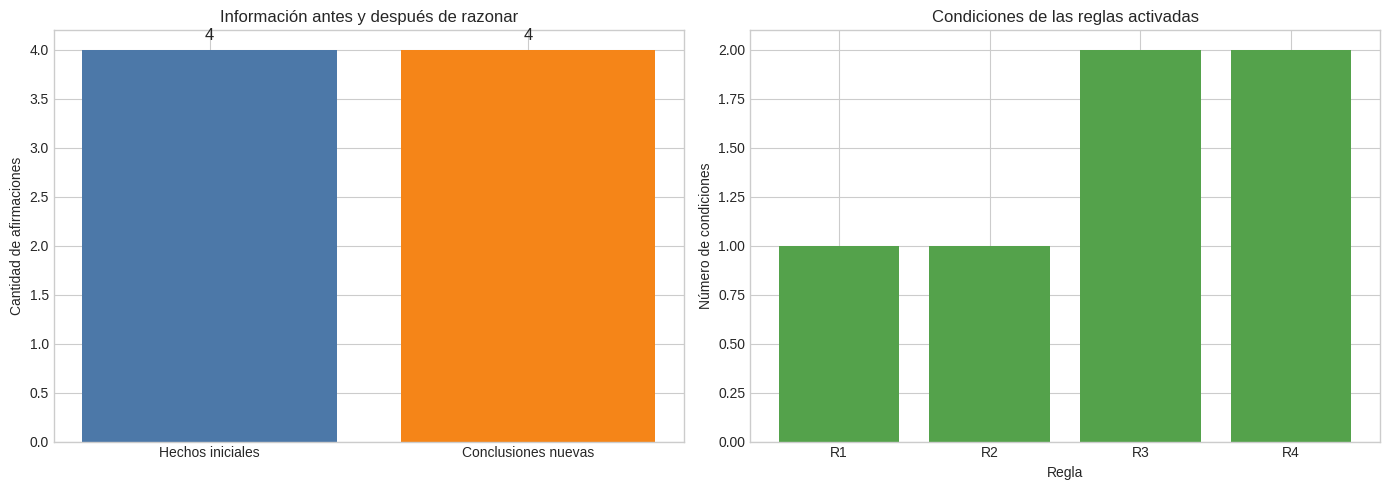

In [6]:
cantidad_iniciales = len(hechos_iniciales)
cantidad_nuevos = len(hechos_finales - hechos_iniciales)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(["Hechos iniciales", "Conclusiones nuevas"],
            [cantidad_iniciales, cantidad_nuevos],
            color=["#4C78A8", "#F58518"])
axes[0].set_title("Información antes y después de razonar")
axes[0].set_ylabel("Cantidad de afirmaciones")
for i, valor in enumerate([cantidad_iniciales, cantidad_nuevos]):
    axes[0].text(i, valor + 0.1, str(valor), ha="center", fontsize=12)

condiciones_por_regla = [len(regla["si"]) for regla in reglas
                         if regla["nombre"] in reglas_activadas]
nombres_cortos = [nombre.split(" - ")[0] for nombre in reglas_activadas]
axes[1].bar(nombres_cortos, condiciones_por_regla, color="#54A24B")
axes[1].set_title("Condiciones de las reglas activadas")
axes[1].set_xlabel("Regla")
axes[1].set_ylabel("Número de condiciones")
plt.tight_layout()
plt.show()

## Explicación detallada de las gráficas

### Gráfica izquierda: información antes y después de razonar

Esta gráfica compara dos momentos del sistema:

- **Hechos iniciales = 4:** son los datos conocidos al comenzar: `suelo_seco`, `temperatura_alta`, `luz_suficiente` y `persona_detectada`.
- **Conclusiones nuevas = 4:** son resultados que el sistema dedujo usando las reglas: `necesita_riego`, `necesita_ventilacion`, `activar_bomba_agua` y `mostrar_alerta`.

La barra naranja no representa aciertos ni porcentaje de precisión. Solo indica cuántas afirmaciones nuevas pudo producir el sistema. Que las dos barras tengan el mismo tamaño significa que hubo cuatro hechos iniciales y cuatro deducciones posteriores.

La cadena de razonamiento fue:

```text
suelo_seco + temperatura_alta + luz_suficiente + persona_detectada
                         ↓ reglas
necesita_riego + necesita_ventilacion
                         ↓ nuevas reglas
activar_bomba_agua + mostrar_alerta
```

En palabras simples: el sistema comenzó con observaciones y terminó con recomendaciones o acciones.

### Gráfica derecha: condiciones de las reglas activadas

Esta gráfica no muestra cuántas veces se ejecutó cada regla. Muestra cuántas condiciones tuvo que revisar cada regla para poder activarse.

- **R1 = 1 condición:** `SI suelo_seco ENTONCES necesita_riego`.
- **R2 = 1 condición:** `SI temperatura_alta ENTONCES necesita_ventilacion`.
- **R3 = 2 condiciones:** `SI necesita_riego Y luz_suficiente ENTONCES activar_bomba_agua`.
- **R4 = 2 condiciones:** `SI persona_detectada Y necesita_ventilacion ENTONCES mostrar_alerta`.

Una regla con dos condiciones es más exigente porque necesita más evidencia. La palabra `Y` significa que ambas condiciones son obligatorias. Si falta una de ellas, la regla no se activa.

### ¿Qué nos enseñan juntas?

La gráfica izquierda muestra **cuánto conocimiento nuevo generó** el sistema. La gráfica derecha muestra **qué tan exigentes fueron las reglas** que utilizó. Juntas ayudan a entender que el razonamiento simbólico sigue una ruta visible: hechos, reglas, conclusiones y acciones.

Por ejemplo, podemos explicar la activación de la bomba así: ‘se activó porque el suelo estaba seco; después se comprobó que había luz suficiente’. Esta explicación es posible porque el sistema conserva la regla y los hechos utilizados.

**Interpretación sencilla:** las conclusiones nuevas son acciones o estados que no estaban escritos al inicio. El sistema las construyó aplicando reglas. Una regla con dos condiciones exige más evidencia antes de activarse que una regla con una sola condición.

## 7. Probar otro escenario

Modificar los hechos permite observar cómo cambia la decisión. En este segundo escenario no hay persona detectada y el suelo está húmedo. Se mantienen la temperatura alta y la luz suficiente.

In [7]:
otro_escenario = {
    "suelo_humedo",
    "temperatura_alta",
    "luz_suficiente"
}

hechos_escenario_2, bitacora_escenario_2, _ = razonar(otro_escenario, reglas)
print("Conclusiones del escenario 2:")
for hecho in sorted(hechos_escenario_2 - otro_escenario):
    print(" →", hecho)

print("\nExplicación:")
for paso in bitacora_escenario_2:
    print(f"{paso['regla']}: {paso['condiciones']} → {paso['conclusion']}")

Conclusiones del escenario 2:
 → necesita_ventilacion

Explicación:
R2 - proteger plantas del calor: temperatura_alta → necesita_ventilacion


**Interpretación sencilla:** como el suelo ya no está seco, no se activa el riego. Como tampoco hay una persona detectada, la regla de alerta no se activa. El sistema conserva solo las conclusiones que están justificadas por los hechos del nuevo escenario.

## Guía ampliada: ¿qué hace cada bloque y por qué?

### Bloque 1 — Preparar herramientas
Importamos las bibliotecas que solo nos ayudan a presentar la información. `pandas` crea tablas y `matplotlib` crea gráficos. Estas herramientas no son el razonamiento simbólico; el razonamiento estará en las reglas y en la función `razonar`.

**Qué debe entender el estudiante:** separar la parte visual de la parte lógica. Podemos cambiar el diseño de los gráficos sin cambiar la forma en que el sistema toma decisiones.

### Bloque 2 — Definir hechos
El conjunto `hechos_iniciales` representa lo que el sistema sabe en un instante. Cada palabra funciona como una afirmación verdadera. Por ejemplo, `suelo_seco` significa que un sensor o una medición previa indicó que el suelo necesita agua.

**Qué debe entender el estudiante:** los hechos son la entrada del razonamiento. Si quitamos un hecho, las reglas que dependían de él podrían dejar de activarse.

### Bloque 3 — Definir reglas
Cada diccionario describe una regla con la estructura `SI condiciones ENTONCES conclusión`. El conjunto en `si` contiene las condiciones que deben estar presentes. `entonces` contiene el hecho nuevo que se agregará si la regla se cumple.

**Qué debe entender el estudiante:** una regla no es una predicción. Es una instrucción lógica creada por una persona. Por eso puede revisarse, corregirse y explicarse.

### Bloque 4 — Crear el motor de inferencia
La función `razonar` comienza copiando los hechos iniciales. Luego revisa las reglas. `issubset` pregunta si todas las condiciones de una regla están presentes. Cuando la respuesta es sí, se agrega la conclusión y se registra la explicación.

El ciclo `while` es importante: vuelve a revisar las reglas porque una conclusión nueva puede convertirse en una condición para otra regla. Esto se llama encadenamiento hacia adelante.

**Qué debe entender el estudiante:** el sistema avanza desde los datos conocidos hacia nuevas conclusiones; no empieza con una respuesta y busca justificarla después.

### Bloque 5 — Leer la explicación
La `bitacora` guarda cada regla activada, sus condiciones y su conclusión. La tabla permite reconstruir el camino lógico. Por ejemplo, si aparece `activar_bomba_agua`, podemos comprobar que antes existían `necesita_riego` y `luz_suficiente`.

**Qué debe entender el estudiante:** una buena IA simbólica puede responder no solo ‘qué decidió’, sino también ‘por qué lo decidió’.

### Bloque 6 — Visualizar la inferencia
Los gráficos convierten el proceso lógico en una imagen. El primer gráfico compara cuántos hechos había al inicio y cuántas conclusiones nuevas se obtuvieron. El segundo muestra cuántas condiciones necesitó cada regla activada.

**Qué debe entender el estudiante:** una visualización no reemplaza la lógica, pero facilita detectar si el proceso produjo pocas, muchas o ninguna conclusión.

### Bloque 7 — Probar otro escenario
Cambiamos los hechos iniciales y ejecutamos el mismo conjunto de reglas. Esto demuestra que las reglas son reutilizables: el sistema cambia su respuesta porque cambió la información disponible, no porque se haya reentrenado.

**Qué debe entender el estudiante:** las decisiones dependen de los hechos. Para probar el sistema, conviene crear escenarios normales, extremos y con información faltante.

## Resumen: razonamiento simbólico frente a aprendizaje automático

| Aspecto | Razonamiento simbólico | Aprendizaje automático |
|---|---|---|
| Fuente del conocimiento | Reglas y hechos definidos explícitamente | Ejemplos y datos históricos |
| Cómo decide | Comprueba condiciones lógicas | Calcula patrones aprendidos |
| Explicación | Normalmente muestra la regla y los hechos usados | Puede requerir técnicas adicionales para explicar el resultado |
| Datos necesarios | Puede funcionar con pocos datos si las reglas son conocidas | Suele necesitar muchos ejemplos representativos |
| Adaptación | Hay que modificar o agregar reglas | Puede reentrenarse con nuevos datos |
| Mejor uso | Políticas, seguridad, diagnósticos con reglas claras y automatización controlada | Imágenes, voz, texto, predicciones y patrones difíciles de describir con reglas |
| Riesgo principal | No contempla situaciones que no fueron previstas | Puede aprender errores o sesgos presentes en los datos |

### Idea clave

El razonamiento simbólico se parece a un experto que dice: ‘si ocurre A y B, entonces recomiendo C’. El aprendizaje automático se parece a un analista que revisa muchos ejemplos y aprende que ciertos patrones suelen relacionarse con C.

En sistemas reales pueden combinarse. Un modelo de aprendizaje automático puede convertir una imagen o una señal en un hecho como `persona_detectada`; después, un sistema simbólico puede aplicar reglas de seguridad para decidir qué acción está permitida. Esta combinación aprovecha la capacidad de reconocer patrones del aprendizaje automático y la capacidad de explicar y controlar decisiones del razonamiento simbólico.

## Conclusiones finales

En este notebook construimos un sistema de razonamiento simbólico desde cero.

- Los **hechos** representan lo que el sistema conoce.
- Las **reglas** representan conocimiento escrito de forma explícita.
- La **inferencia** aplica las reglas y genera conclusiones nuevas.
- La **bitácora** permite explicar cada decisión.
- Cambiar los hechos cambia las acciones recomendadas.

### Ventajas observadas

El método es fácil de auditar, no necesita un conjunto grande de datos y puede funcionar localmente en un dispositivo.

### Limitaciones observadas

Alguien debe escribir y actualizar las reglas. Si aparece una situación no prevista, el sistema puede no saber qué hacer. Además, los sensores deben transformar sus mediciones correctamente en hechos simbólicos.

### Siguiente paso recomendado

Agregar reglas de seguridad, por ejemplo: `SI tanque_vacio ENTONCES no_activar_bomba`, y estudiar cómo resolver conflictos cuando dos reglas recomiendan acciones opuestas.